# Análisis exploratorio del precio de BTC para definir la variable objetivo
---

# Configuración de ambiente

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# import xgboost as xgb
# from sklearn.preprocessing import LabelEncoder, StandardScaler

# import lightgbm as lgb

# Carga de modulos_apex
from modulos_apex_dev import BTC_DataExtractor_ccxt as ccxt #, trading_backtester as tbt
from modulos_apex_dev import DataExtractor_ccxt_v2 as ccxt_v2
from modulos_apex_dev.modulo_final.pipeline import BTCPipeline
from modulos_apex_dev.modulo_final.detector_extremos_jerarquico import etiquetar_jerarquico, resumen_etiquetas

import os
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")
np.set_printoptions(threshold=sys.maxsize)
pd.set_option(
    "display.max_rows", None, 
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
    "display.precision", 1,
    "display.float_format" ,'{:,.4f}'.format)

CURRENT_DIR = os.getcwd()

# Carga de precios históricos de BTC desde Binance
---


In [2]:
CURRENT_DIR

'/Users/julesaccm/Documents/Repos/Apex-project/notebooks'

In [3]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    btc = pd.read_csv('ccxt_btc_historical.csv', index_col=0)
    print("Datos cargados desde 'data/processed/ccxt_btc_historical.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor_ccxt = ccxt.ExtractorDatosCCXT(
        exchange_id='binance', 
        symbol='BTC/USDT', 
        timeframe='1d', 
        # ventana_critica=14
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    btc = extractor_ccxt.obtener_datos(
        start_date="2018-01-01",
        end_date="2026-04-10",
        buffer_dias=34
    )

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    btc = extractor_ccxt.etiquetar_puntos_criticos(btc, ventana_critica=7)
    btc = extractor_ccxt.etiquetar_puntos_criticos(btc, ventana_critica=14)

    # # Paso C: Calcular todo el análisis técnico
    # df_con_indicadores_c = extractor_ccxt.agregar_indicadores_avanzados(df_etiquetado_c)

    # # Paso D: Enriquecer con datos macroeconómicos
    # df_final = extractor_ccxt.agregar_contexto_macro(df_con_indicadores_c)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(btc.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    btc.to_csv('data/processed/ccxt_btc_historical.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/ccxt_btc_historical.csv'")

finally:
    os.chdir(CURRENT_DIR) 


Archivo no encontrado. Ejecutando el pipeline para generar los datos...
[CCXT] Descargando BTC/USDT desde 2017-11-28...

--- Vista previa de las primeras 5 filas ---
                  Open        High         Low       Close      Volume  \
Date                                                                     
2017-11-28  9,650.0000  9,939.0000  9,570.5000  9,896.8000  4,917.2110   
2017-11-29  9,896.7900 11,300.0300  8,520.0000  9,687.8800 13,352.5387   
2017-11-30  9,687.8800 10,900.0000  8,850.8000  9,838.9600  9,389.5743   
2017-12-01  9,837.0000 10,898.0000  9,380.0000 10,782.9900  6,134.9236   
2017-12-02 10,775.0400 11,190.0000 10,620.0000 10,890.0100  4,765.4398   

            Retorno_Log  Target_7P  Target_14P  
Date                                            
2017-11-28          NaN          0           0  
2017-11-29      -0.0213          0           0  
2017-11-30       0.0155          0           0  
2017-12-01       0.0916          0           0  
2017-12-02       0.00

In [4]:
btc.tail(60)

,Open,High,Low,Close,Volume,Retorno_Log,Target_7P,Target_14P
Date,,,,,,,,
2026-02-10,"70,138.0000","70,527.5900","67,800.0000","68,841.2900","20,373.7707",-0.0187,0,0
2026-02-11,"68,841.2800","69,292.8800","65,756.0000","67,082.5200","28,718.2460",-0.0259,0,0
2026-02-12,"67,082.5200","68,410.5200","65,118.0000","66,272.1700","24,271.7428",-0.0122,0,0
2026-02-13,"66,272.1700","69,482.9700","65,872.4600","68,853.9600","20,244.5495",0.0382,0,0
2026-02-14,"68,853.9700","70,560.0100","68,730.1300","69,822.9500","18,114.7839",0.0140,0,0
2026-02-15,"69,822.9400","70,983.0000","68,000.0000","68,832.5800","22,290.0521",-0.0143,0,0
2026-02-16,"68,832.5900","70,126.6700","67,294.1100","68,892.4300","15,515.7653",0.0009,0,0
2026-02-17,"68,892.4300","69,241.5000","66,621.0600","67,503.5200","16,489.0692",-0.0204,0,0
2026-02-18,"67,503.5200","68,476.2200","65,870.0000","66,461.0000","15,492.4384",-0.0156,0,0


In [5]:
btc.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,"3,056.0000","38,244.5475","32,394.9037","3,211.7100","9,659.6450","28,049.4200","60,096.2950","124,658.5400"
High,"3,056.0000","39,051.2845","32,914.0948","3,276.5000","9,880.4725","28,537.4800","61,481.8925","126,199.6300"
Low,"3,056.0000","37,369.8928","31,835.7859","3,156.2600","9,351.7500","27,385.3800","58,603.3150","123,084.0000"
Close,"3,056.0000","38,265.2900","32,396.8731","3,211.7200","9,664.4325","28,066.6300","60,229.7600","124,658.5400"
Volume,"3,056.0000","63,230.0722","76,471.4133","1,521.5373","24,953.8954","39,835.1970","65,908.0169","760,705.3628"
Retorno_Log,"3,055.0000",0.0007,0.0355,-0.5026,-0.0140,0.0005,0.0154,0.2030
Target_7P,"3,056.0000",-0.0033,0.2951,-1.0000,0.0000,0.0000,0.0000,1.0000
Target_14P,"3,056.0000",0.0003,0.2133,-1.0000,0.0000,0.0000,0.0000,1.0000


In [8]:
print(btc['Target_7P'].value_counts(dropna=False),
      btc['Target_14P'].value_counts(dropna=False))

Target_7P
 0    2790
-1     138
 1     128
Name: count, dtype: int64 Target_14P
 0    2917
 1      70
-1      69
Name: count, dtype: int64


In [9]:
print(btc['Target_7P'].value_counts(dropna=False,normalize=True),
      btc['Target_14P'].value_counts(dropna=False,normalize=True))

Target_7P
 0   0.9130
-1   0.0452
 1   0.0419
Name: proportion, dtype: float64 Target_14P
 0   0.9545
 1   0.0229
-1   0.0226
Name: proportion, dtype: float64


Gráfica del precio del BTC

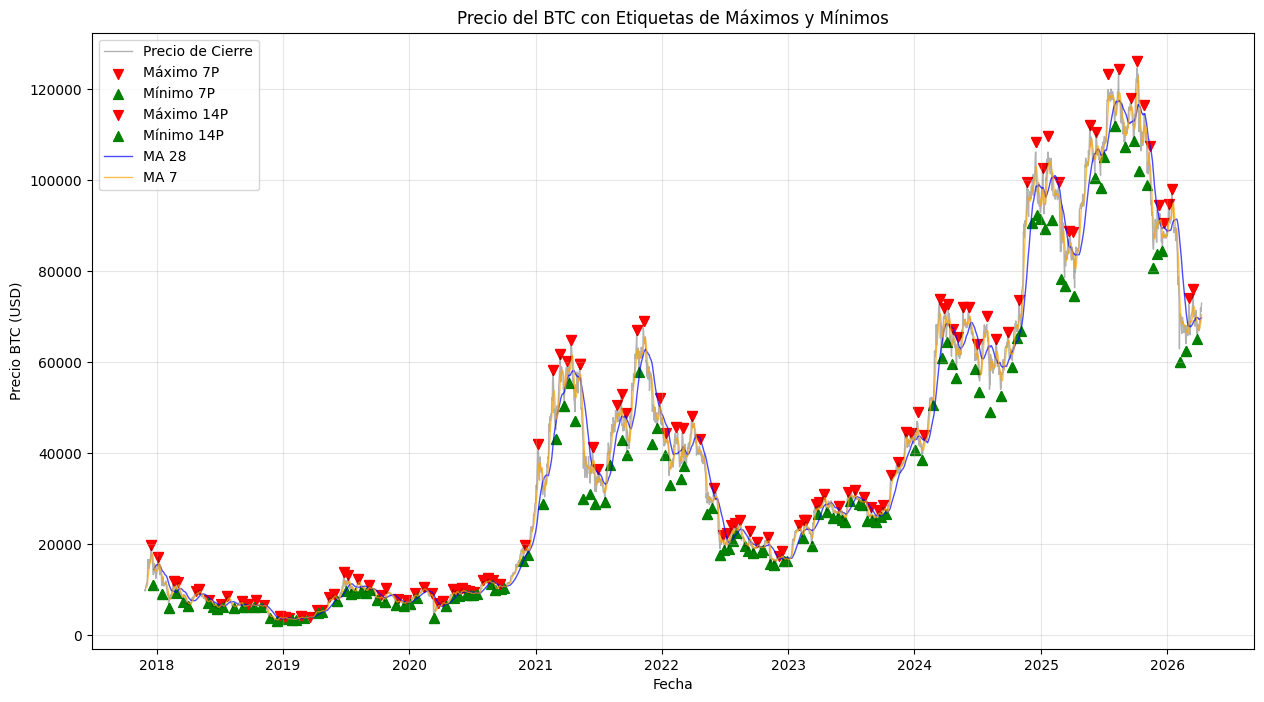

In [13]:
titulo="Precio del BTC con Etiquetas de Máximos y Mínimos"
plt.figure(figsize=(15, 8))

# 1. Graficamos el precio de cierre como referencia
plt.plot(btc.index, btc['Close'], label='Precio de Cierre', color='black', alpha=0.3, lw=1)

# 2. Resaltamos los Máximos (Target == 1) usando el High
maximos = btc[btc['Target_7P'] == 1]
plt.scatter(maximos.index, maximos['High'], color='red', label='Máximo 7P', marker='v', s=50)

# 3. Resaltamos los Mínimos (Target == -1) usando el Low
minimos = btc[btc['Target_7P'] == -1]
plt.scatter(minimos.index, minimos['Low'], color='green', label='Mínimo 7P', marker='^', s=50)

# 2. Resaltamos los Máximos (Target == 1) usando el High
maximos14 = btc[btc['Target_14P'] == 1]
plt.scatter(maximos14.index, maximos14['High'], color='red', label='Máximo 14P', marker='v', s=50)

# 3. Resaltamos los Mínimos (Target == -1) usando el Low
minimos14 = btc[btc['Target_14P'] == -1]
plt.scatter(minimos14.index, minimos14['Low'], color='green', label='Mínimo 14P', marker='^', s=50)

# 4. Agregamos la media móvil de 28 periodos para contexto
btc['MA28'] = btc['Close'].rolling(window=28).mean()
plt.plot(btc.index, btc['MA28'], label='MA 28', color='blue', alpha=0.7, lw=1)

# 5. Agregamos la media móvil de 7 periodos para contexto
btc['MA7'] = btc['Close'].rolling(window=7).mean()
plt.plot(btc.index, btc['MA7'], label='MA 7', color='orange', alpha=0.7, lw=1)

plt.title(titulo)
plt.xlabel('Fecha')
plt.ylabel('Precio BTC (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
def grafica_btc(df:pd.DataFrame, titulo:str, variable:str, target_col: bool, y_label: str, variable_label:str):
    plt.figure(figsize=(15, 8))

    # 1. Graficamos el precio de cierre como referencia
    plt.plot(df.index, df[variable], label=variable_label, color='black', alpha=0.7, lw=1)

    # # 2. Resaltamos los Máximos (Target == 1) usando el High
    # maximos = btc[btc['Target_7P'] == 1]
    # plt.scatter(maximos.index, maximos['High'], color='red', label='Máximo 7P', marker='v', s=20)

    # # 3. Resaltamos los Mínimos (Target == -1) usando el Low
    # minimos = btc[btc['Target_7P'] == -1]
    # plt.scatter(minimos.index, minimos['Low'], color='green', label='Mínimo 7P', marker='^', s=20)

    # # 2. Resaltamos los Máximos (Target == 1) usando el High
    # maximos14 = btc[btc['Target_14P'] == 1]
    # plt.scatter(maximos14.index, maximos14['High'], color='red', label='Máximo 14P', marker='v', s=20)

    # # 3. Resaltamos los Mínimos (Target == -1) usando el Low
    # minimos14 = btc[btc['Target_14P'] == -1]
    # plt.scatter(minimos14.index, minimos14['Low'], color='green', label='Mínimo 14P', marker='^', s=20)

    # 4. Agregamos la media móvil de 28 periodos para contexto
    df['MA28'] = df[variable].rolling(window=28).mean()
    plt.plot(df.index, df['MA28'], label='MA 28', color='blue', alpha=0.4, lw=1)

    # 5. Agregamos la media móvil de 7 periodos para contexto
    df['MA7'] = df[variable].rolling(window=7).mean()
    plt.plot(df.index, df['MA7'], label='MA 7', color='orange', alpha=0.4, lw=1)

    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


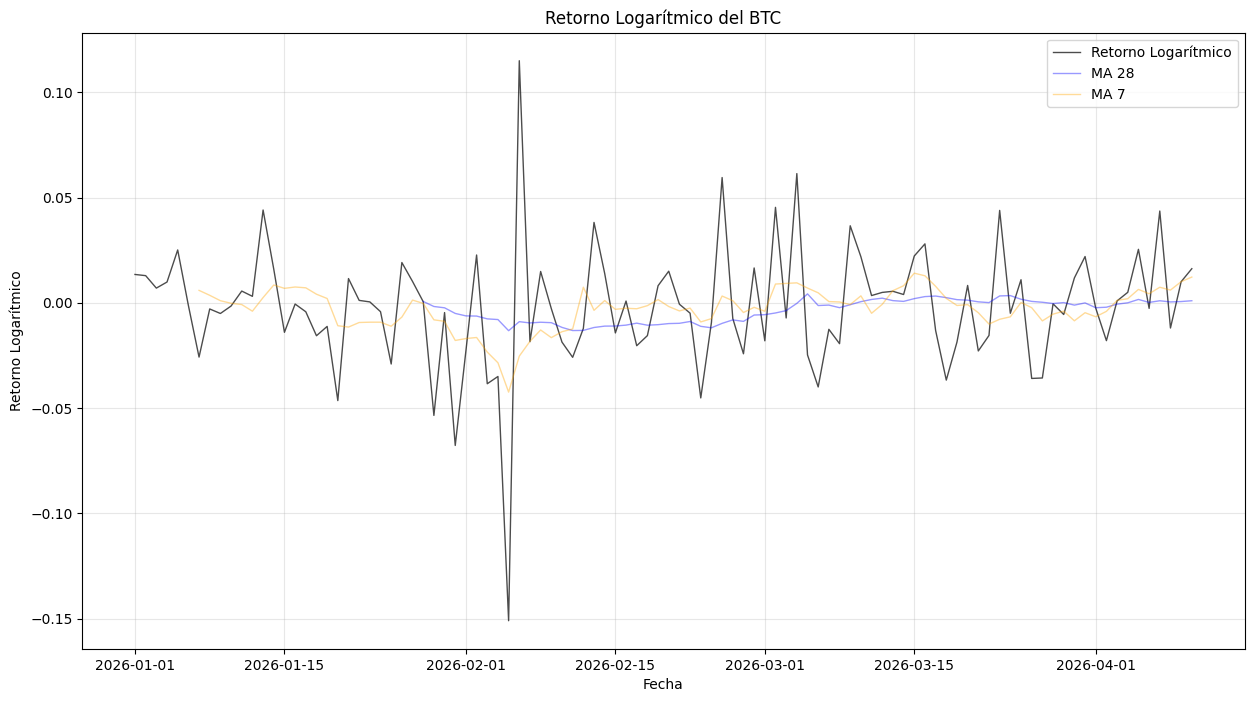

In [19]:
grafica_btc(
    btc.loc[btc.index >= '2026-01-01'],
    titulo="Retorno Logarítmico del BTC",
    variable="Retorno_Log",
    target_col=False,
    y_label="Retorno Logarítmico",
    variable_label="Retorno Logarítmico"
)

## Análisis de Targets
---

In [63]:
# 1. Instanciar la clase (Configuramos las variables globales del proceso)
extractor_ccxt_v2 = ccxt_v2.ExtractorDatosCCXT(
    exchange_id='binance', 
    symbol='BTC/USDT', 
    timeframe='1d', 
    # ventana_critica=14
)

# 2. Ejecutar las transformaciones en cadena (Pipeline)
# Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

# Paso A: Obtener el precio histórico y volumen
btc2 = extractor_ccxt_v2.obtener_datos(
    start_date="2018-01-01",
    end_date="2026-04-13",
    buffer_dias=34
)

# Paso B: Etiquetar máximos y mínimos (Nuestro Target)
btc2 = extractor_ccxt_v2.etiquetar_puntos_criticos(btc2, ventana_critica=14, tolerancia_extremo=0.0025)
# btc2 = extractor_ccxt_v2.etiquetar_puntos_criticos(btc2, ventana_critica=14, tolerancia_extremo=0.005)

btc2 = extractor_ccxt_v2.etiquetar_con_derivada_suavizada(btc2, ventana_suave=14)

# 3. Revisar el resultado final
print("\n--- Vista previa de las primeras 5 filas ---")
print(btc2.head())

# # Creamos el archivo en la carpeta data/processed
# os.chdir(CURRENT_DIR)
# os.chdir('..')
# os.makedirs('data/processed', exist_ok=True)
# btc2.to_csv('data/processed/ccxt_btc_historical_v2.csv', index=True)


[CCXT] Descargando BTC/USDT desde 2017-11-28...

--- Vista previa de las primeras 5 filas ---
                  Open        High         Low       Close      Volume  \
Date                                                                     
2017-11-28  9,650.0000  9,939.0000  9,570.5000  9,896.8000  4,917.2110   
2017-11-29  9,896.7900 11,300.0300  8,520.0000  9,687.8800 13,352.5387   
2017-11-30  9,687.8800 10,900.0000  8,850.8000  9,838.9600  9,389.5743   
2017-12-01  9,837.0000 10,898.0000  9,380.0000 10,782.9900  6,134.9236   
2017-12-02 10,775.0400 11,190.0000 10,620.0000 10,890.0100  4,765.4398   

            Retorno_Log  Max_Local  Min_Local  target_max_14P  target_min_14P  \
Date                                                                            
2017-11-28          NaN        NaN        NaN               0               0   
2017-11-29      -0.0213        NaN        NaN               0               0   
2017-11-30       0.0155        NaN        NaN               0  

In [64]:
# Probando la funcion mejorada con Claude
from modulos_apex_dev.detector_extremos_locales import etiquetar_extremos_validados as eev

In [71]:
btc2 = eev(df=btc2, ventana_critica=7, smooth_poly=3)

In [72]:
btc2.head()

,Open,High,Low,Close,Volume,Retorno_Log,Max_Local,Min_Local,target_max_14P,target_min_14P,target_max_dt_14,extremo_tipo,extremo_validado,extremo_strength,extremo_precio,d1,d2,pct_change
Date,,,,,,,,,,,,,,,,,,
2017-11-28,"9,650.0000","9,939.0000","9,570.5000","9,896.8000","4,917.2110",NaN,NaN,NaN,0,0,0,0,0,0.0000,NaN,0.0000,0.0000,NaN
2017-11-29,"9,896.7900","11,300.0300","8,520.0000","9,687.8800","13,352.5387",-0.0213,NaN,NaN,0,0,0,-1,1,0.0000,"8,520.0000",-365.4417,630.4155,NaN
2017-11-30,"9,687.8800","10,900.0000","8,850.8000","9,838.9600","9,389.5743",0.0155,NaN,NaN,0,0,0,0,0,0.0000,NaN,0.0000,0.0000,NaN
2017-12-01,"9,837.0000","10,898.0000","9,380.0000","10,782.9900","6,134.9236",0.0916,NaN,NaN,0,0,0,0,0,0.0000,NaN,0.0000,0.0000,NaN
2017-12-02,"10,775.0400","11,190.0000","10,620.0000","10,890.0100","4,765.4398",0.0099,NaN,NaN,0,0,0,0,0,0.0000,NaN,0.0000,0.0000,NaN


In [73]:
print(btc2['target_max_14P'].value_counts(dropna=False),
      btc2['target_min_14P'].value_counts(dropna=False),
      btc2['extremo_tipo'].value_counts(dropna=False),
      "\n"+10*"="+"Proporciones"+10*"="+"\n",
      btc2['target_max_14P'].value_counts(dropna=False,normalize=True),
      btc2['target_min_14P'].value_counts(dropna=False,normalize=True),
      btc2['extremo_tipo'].value_counts(dropna=False, normalize=True))

target_max_14P
0    2970
2      70
1      19
Name: count, dtype: int64 target_min_14P
0    2978
2      70
1      11
Name: count, dtype: int64 extremo_tipo
 0    2893
-1      83
 1      83
Name: count, dtype: int64 
==========Proporciones==========
 target_max_14P
0   0.9709
2   0.0229
1   0.0062
Name: proportion, dtype: float64 target_min_14P
0   0.9735
2   0.0229
1   0.0036
Name: proportion, dtype: float64 extremo_tipo
 0   0.9457
-1   0.0271
 1   0.0271
Name: proportion, dtype: float64


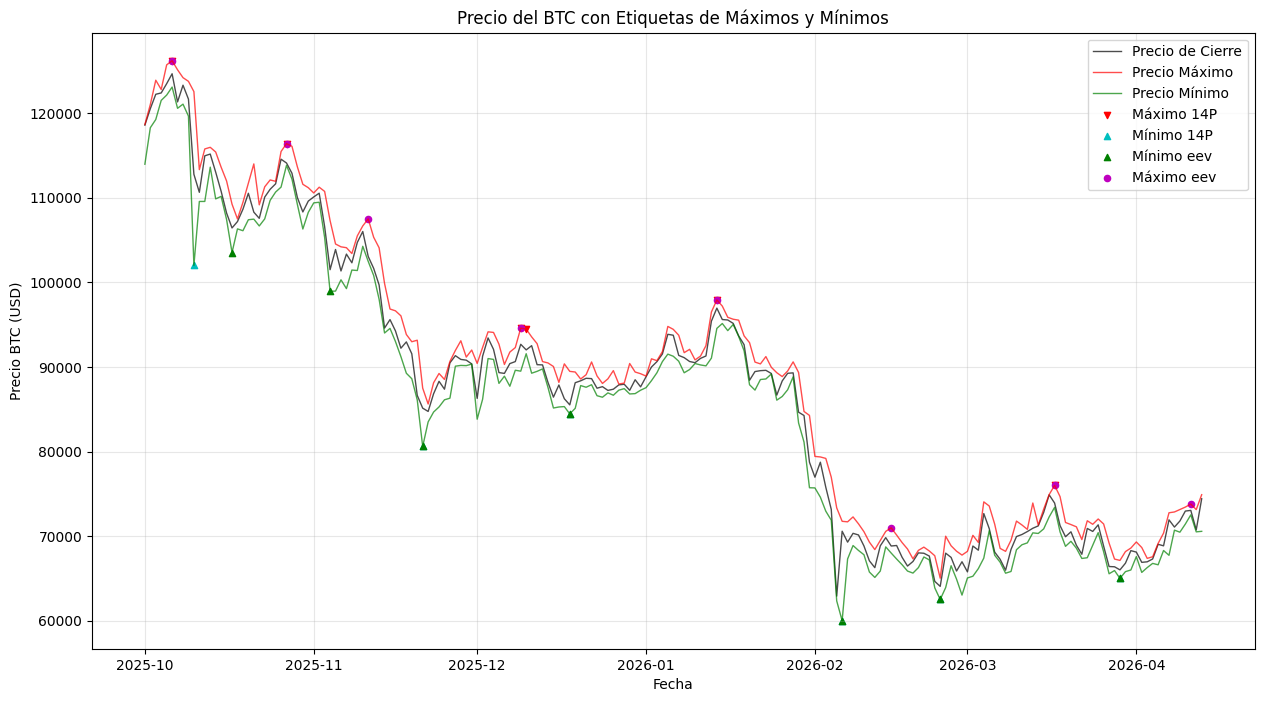

In [74]:
btc_graph = btc2.loc[btc2.index >= '2025-10-01']

titulo="Precio del BTC con Etiquetas de Máximos y Mínimos"
plt.figure(figsize=(15, 8))

# 1. Graficamos el precio de cierre como referencia
plt.plot(btc_graph.index, btc_graph['Close'], label='Precio de Cierre', color='black', alpha=0.7, lw=1)

plt.plot(btc_graph.index, btc_graph['High'], label='Precio Máximo', color='r', alpha=0.7, lw=1)

plt.plot(btc_graph.index, btc_graph['Low'], label='Precio Mínimo', color='g', alpha=0.7, lw=1)

# 2. Resaltamos los Máximos (Target == 1) usando el High
maximos = btc_graph[btc_graph['target_max_14P'] > 0]
plt.scatter(maximos.index, maximos['High'], color='red', label='Máximo 14P', marker='v', s=20)

minimos = btc_graph[btc_graph['target_min_14P'] > 0]
plt.scatter(minimos.index, minimos['Low'], color='c', label='Mínimo 14P', marker='^', s=20)

# maximos = btc_graph[btc_graph['target_max_dt_7'] > 0]
# plt.scatter(maximos.index, maximos['High'], color='b', label='Máximo (dt) 7P', marker='*', s=20)

# 3. Resaltamos los Mínimos (Target == -1) usando el Low
minimos = btc_graph[btc_graph['extremo_tipo'] < 0]
plt.scatter(minimos.index, minimos['Low'], color='green', label='Mínimo eev', marker='^', s=20)

# 2. Resaltamos los Máximos (Target == 1) usando el High
maximos = btc_graph[btc_graph['extremo_tipo'] > 0]
plt.scatter(maximos.index, maximos['High'], color='m', label='Máximo eev', marker='o', s=20)

# # 3. Resaltamos los Mínimos (Target == -1) usando el Low
# minimos14 = btc2[btc2['target_min_14P'] > 0]
# plt.scatter(minimos14.index, minimos14['Low'], color='green', label='Mínimo 14P', marker='^', s=20)

# # 4. Agregamos la media móvil de 28 periodos para contexto
# btc_graph['MA3'] = btc_graph['Close'].ewm(span=3).mean()
# plt.plot(btc_graph.index, btc_graph['MA3'], label='MA 3', color='blue', alpha=0.5, lw=1)

# # 5. Agregamos la media móvil de 7 periodos para contexto
# btc_graph['MA7'] = btc_graph['Close'].ewm(span=7).mean()
# plt.plot(btc_graph.index, btc_graph['MA7'], label='MA 7', color='orange', alpha=0.5, lw=1)

plt.title(titulo)
plt.xlabel('Fecha')
plt.ylabel('Precio BTC (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**¿Cuáles deben de ser las características necesarias para el precio del BTC se encuentre en un extremo (mínimo o máximo)?**

1. Debe encontrarse en una ventana de tiempo `n`.
2. Los extremos deben de intercalarse en al menos `n` periodos, es decir, si hay un mínimo local en `t=1`, el siguiente punto extremo deberá encontrarse en al menos `t=5` (con `n=4`) periodos de distancia.
3. El cambio entre un extremo y otro debe ser considerable (>2% en variación porcentual).
4. Considerar las derivadas de la serie suavizada para considerar posibles extremos dentro de la ventana `n` (lo más pegado posible al extremo local).

In [75]:
btc2.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Retorno_Log', 'Max_Local',
       'Min_Local', 'target_max_14P', 'target_min_14P', 'target_max_dt_14',
       'extremo_tipo', 'extremo_validado', 'extremo_strength',
       'extremo_precio', 'd1', 'd2', 'pct_change'],
      dtype='object')

In [ ]:
btc2['target_max'] = np.where(btc2['extremo_tipo']==1,1,0)
btc2['target_min'] = np.where(btc2['extremo_tipo']==-1,1,0)

# Prueba del nuevo modulo
---

In [7]:
# Funcion para graficar
def graficar_extremos(df_btc, targets: list, since):
    btc_graph = df_btc[['High','Close','Low']+targets].copy()
    btc_graph = btc_graph.loc[df_btc.index >= since]

    titulo=f"Precio del BTC con Etiquetas de Máximos y Mínimos en {btc_graph.shape[0]} días"
    plt.figure(figsize=(15, 8))

    # 1. Graficamos el precio de cierre como referencia
    plt.plot(btc_graph.index, btc_graph['Close'], label='Precio de Cierre', color='black', alpha=0.7, lw=1)

    plt.plot(btc_graph.index, btc_graph['High'], label='Precio Máximo', color='r', alpha=0.7, lw=1)

    plt.plot(btc_graph.index, btc_graph['Low'], label='Precio Mínimo', color='g', alpha=0.7, lw=1)

    # 2. Resaltamos los Máximos (Target == 1) usando el High
    maximos = btc_graph[btc_graph[targets[0]] > 0]
    plt.scatter(maximos.index, maximos['High'], color='red', label='Máximo', marker='v', s=20)

    minimos = btc_graph[btc_graph[targets[1]] > 0]
    plt.scatter(minimos.index, minimos['Low'], color='c', label='Mínimo', marker='^', s=20)

    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel('Precio BTC (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [3]:
labels = pd.DataFrame()
for m in ['rolling','forward','savgol']:
    pipe = BTCPipeline(exchange_id="binance", symbol="BTC/USDT", timeframe="1d", keep_meta=False, labeler_method=m)
    df   = pipe.run("2018-01-01", "2026-04-10")
    if m == 'rolling':
        labels = df[['High','Close','Low','target_max','target_min']].rename(columns={'target_max':f'max_{m}','target_min':f'min_{m}'})
    else:
        labels = pd.concat([labels, df[['target_max','target_min']].rename(columns={'target_max':f'max_{m}','target_min':f'min_{m}'})],axis=1)
    


  BTC ML PIPELINE — Inicio

[1/11] Extrayendo datos OHLCV via ccxt...
[ccxt] Descargando BTC/USDT | 1d | desde 2017-11-22 hasta 2026-04-10
[ccxt] Filas descargadas: 3,062  |  Rango: 2017-11-22 00:00:00+00:00 → 2026-04-10 00:00:00+00:00

[2/11] Etiquetando extremos locales...
[Labeler/rolling] target_max=180 (5.9%)  target_min=194 (6.3%)  neutral=2688 (87.8%)

[3-10/11] Calculando features técnicas...
    ✓ TechnicalFeatures         →  27 features  (1.0s)
    ✓ MomentumExtFeatures       →  20 features  (0.0s)
    ✓ TrendExtFeatures          →  34 features  (0.6s)
    ✓ VolumeExtFeatures         →  18 features  (0.4s)
    ✓ CandleFeatures            →  36 features  (0.4s)
    ✓ TemporalFeatures          →  12 features  (0.0s)
    ✓ OnChainFeatures           →   0 features  (0.0s)
    ✓ ExtremeDistanceFeatures   →  11 features  (0.8s)

[11/11] Descargando y calculando features macro...
  [macro] Descargando SP500 (^GSPC)...
  [macro] Descargando VIX (^VIX)...
  [macro] Descargando Gold (

In [4]:
labels.shape

(3028, 9)

In [34]:
labels.tail()

,High,Close,Low,max_rolling,min_rolling,max_forward,min_forward,max_savgol,min_savgol
Date,,,,,,,,,
2026-04-06 00:00:00+00:00,"70,351.4600","68,853.6600","68,300.0000",0,0,0,0,0,0
2026-04-07 00:00:00+00:00,"72,761.0000","71,924.2200","67,732.0100",0,0,0,0,0,0
2026-04-08 00:00:00+00:00,"72,857.0000","71,069.9300","70,707.2300",0,0,0,0,0,0
2026-04-09 00:00:00+00:00,"73,145.0000","71,787.9700","70,466.0000",0,0,0,0,0,0
2026-04-10 00:00:00+00:00,"73,434.0000","72,962.7000","71,426.1500",0,0,0,0,0,0


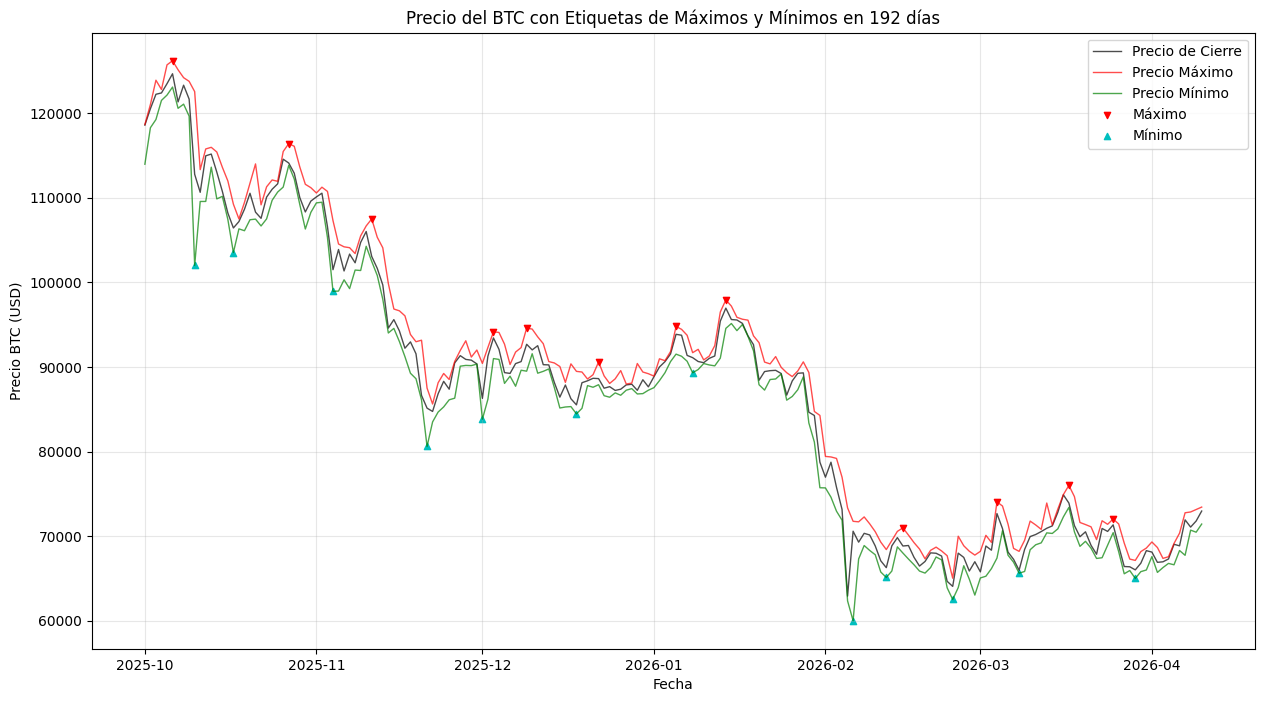

In [35]:
# rolling
graficar_extremos(labels, ['max_rolling','min_rolling'],'2025-10-01')

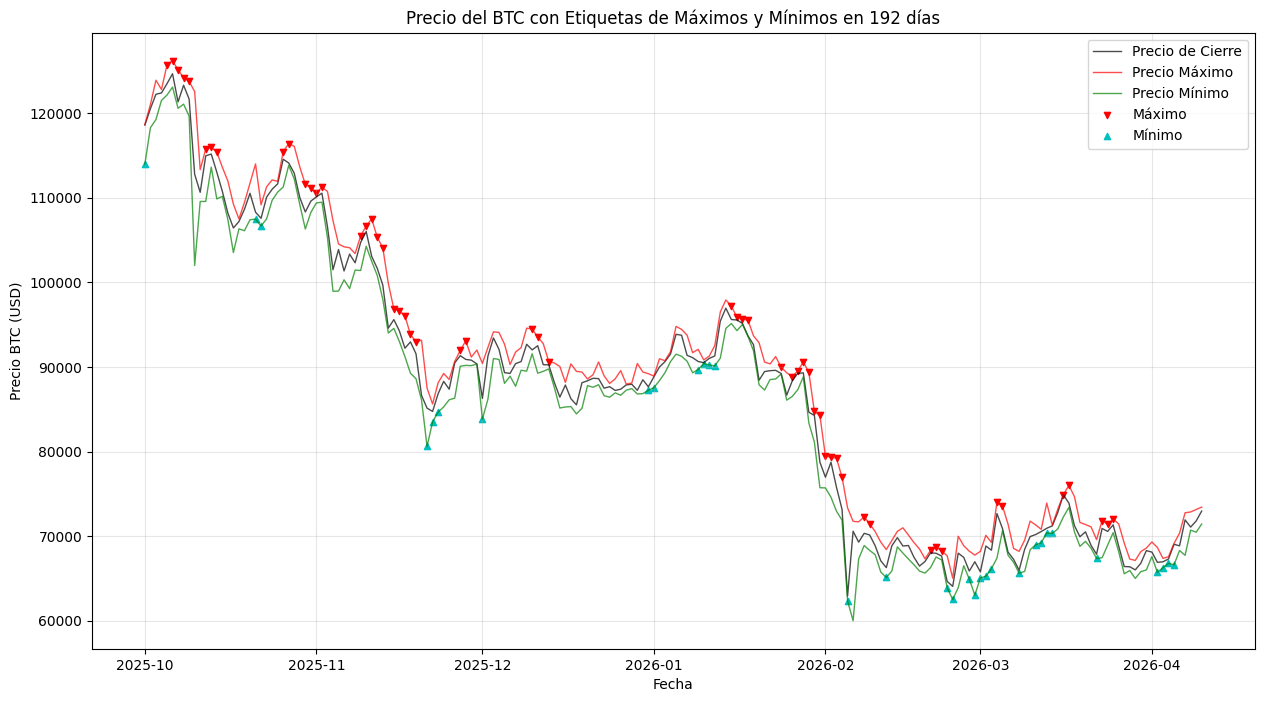

In [37]:
# forward
graficar_extremos(labels, ['max_forward','min_forward'],'2025-10-01')

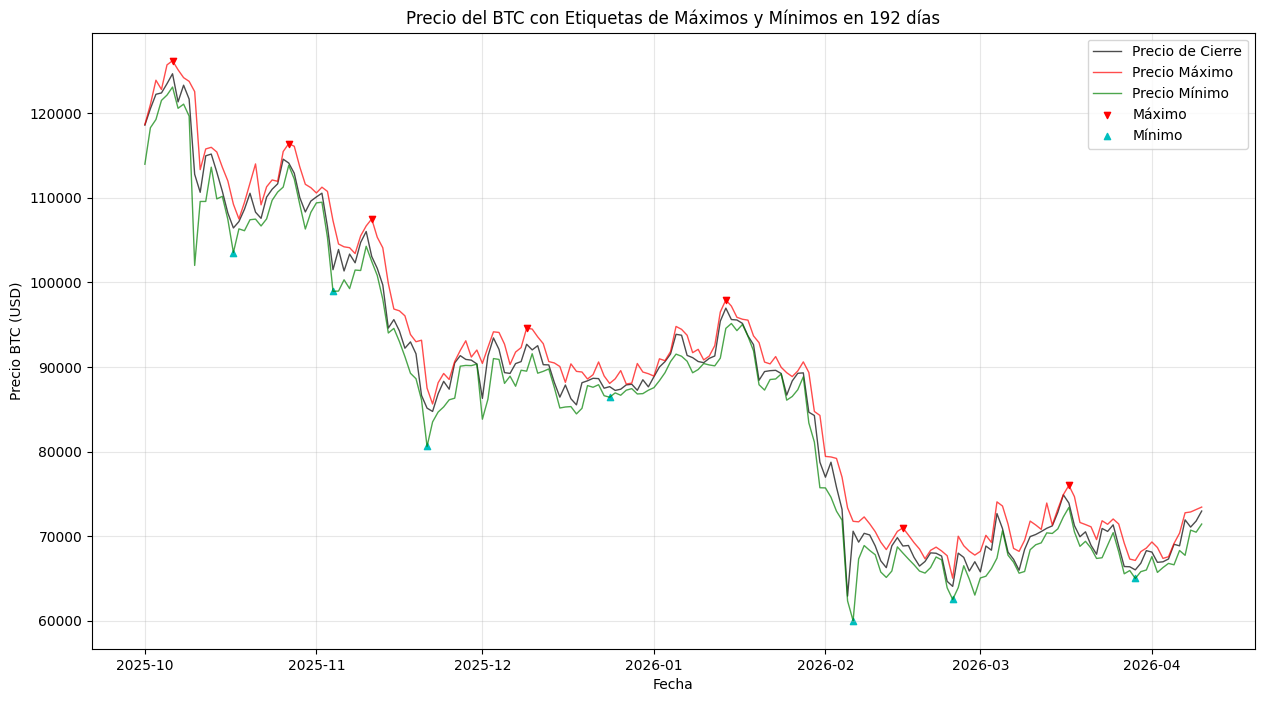

In [38]:
# savgol
graficar_extremos(labels, ['max_savgol','min_savgol'],'2025-10-01')

In [14]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Open,"3,028.0000","38,466.1321","32,460.6580","3,211.7100","9,609.8400","28,405.6000","60,388.8325","124,658.5400"
High,"3,028.0000","39,271.7786","32,984.3813","3,276.5000","9,839.0100","28,989.1800","61,719.9900","126,199.6300"
Low,"3,028.0000","37,594.3725","31,895.5202","3,156.2600","9,345.7500","27,846.0400","58,950.2500","123,084.0000"
Close,"3,028.0000","38,485.7439","32,463.5931","3,211.7200","9,609.8475","28,419.9950","60,445.3800","124,658.5400"
Volume,"3,028.0000","63,704.0090","76,661.4571","1,521.5373","25,402.9336","40,118.2406","66,683.3485","760,705.3628"
Retorno_Log,"3,028.0000",0.0006,0.0349,-0.5026,-0.0140,0.0005,0.0153,0.1784
target_max,"3,028.0000",0.0591,0.2359,0.0000,0.0000,0.0000,0.0000,1.0000
target_min,"3,028.0000",0.0637,0.2443,0.0000,0.0000,0.0000,0.0000,1.0000
RSI_14,"3,028.0000",51.7573,13.4937,10.4978,42.5418,50.4557,60.5344,89.9922
BBL_20_2.0_2.0,"3,028.0000","34,705.4787","30,240.3423","2,909.3927","8,677.8685","25,919.9544","54,044.7838","116,631.1003"


# Etiquetado jerarquico
---

In [5]:
labels.columns.tolist()[:10]

['High',
 'Close',
 'Low',
 'max_rolling',
 'min_rolling',
 'max_forward',
 'min_forward',
 'max_savgol',
 'min_savgol']

In [3]:
test_ = labels[['High','Low','Close','max_rolling','min_rolling','max_forward','min_forward','max_savgol','min_savgol']].copy()

labels_2 = etiquetar_jerarquico(test_, ventana_critica=5, cambio_minimo=0.06)

NameError: name 'labels' is not defined

In [9]:
resumen_etiquetas(labels_2)

,máximos,mínimos,total,peso_total,Δ%_medio,t_val_medio
clase,,,,,,
2 — SG alta conf.,108,108,216,216.0000,18.1%,—
1 — TS baja conf.,123,103,226,90.4000,—,3.59
0 — Neutral,0,0,2586,0.0000,—,—


In [12]:
labels_2['min_savgol'].value_counts()

min_savgol
0    2920
1     108
Name: count, dtype: int64

In [14]:
labels_2['label_tipo'].value_counts(dropna=False)

label_tipo
 0    2586
 1     231
-1     211
Name: count, dtype: int64

In [17]:
labels_2['label_conf'].value_counts()

label_conf
neutral    2586
ts_low      226
sg_high     216
Name: count, dtype: int64

In [20]:
labels_2[['label_hier','label_tipo']].value_counts()

label_hier  label_tipo
0            0            2586
1            1             123
2           -1             108
             1             108
1           -1             103
Name: count, dtype: int64

In [29]:
labels_2["target_max"] = np.select(
    [(labels_2["label_hier"] ==  2) & (labels_2["label_tipo"] == 1),
        (labels_2["label_hier"] ==  1) & (labels_2["label_tipo"] == 1)],
        [2,1]).astype(int)

labels_2["target_min"] = np.select(
    [(labels_2["label_hier"] ==  2) & (labels_2["label_tipo"] == -1),
        (labels_2["label_hier"] ==  1) & (labels_2["label_tipo"] == -1)],
        [2,1]).astype(int)
labels_2 = labels_2.rename(columns={'target_max':f'max_sg_ts','target_min':f'min_sg_ts'})

In [28]:
labels_2['target_max'].value_counts()

target_max
0    2797
1     123
2     108
Name: count, dtype: int64

In [30]:
# Meta data
list(set(labels_2.columns)-set(['High','Low','Close','max_rolling','min_rolling','max_forward','min_forward','max_savgol','min_savgol']))

['d1',
 'd2',
 'min_sg_ts',
 'label_tipo',
 'extremo_tipo',
 'label_conf',
 'ts_t_val',
 'extremo_precio',
 'pct_change',
 'extremo_validado',
 'extremo_strength',
 'label_hier',
 'sample_weight',
 'max_sg_ts']

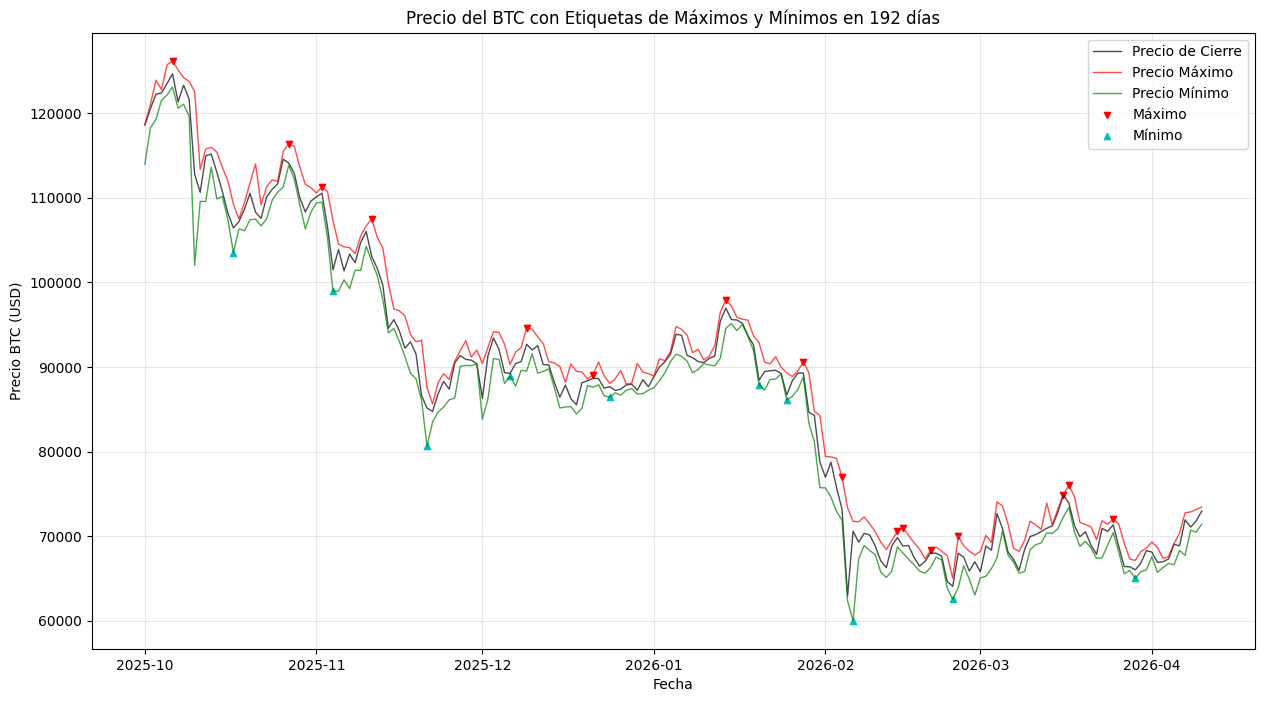

In [32]:
# savgol-ts
graficar_extremos(labels_2, ['max_sg_ts','min_sg_ts'],'2025-10-01')

# Validación del pipeline actualizado con `savgol-ts`
---

In [9]:
labels = pd.DataFrame()
for m in ['savgol-ts']:#['rolling','forward','savgol','savgol-ts']:
    pipe = BTCPipeline(exchange_id="binance", symbol="BTC/USDT", timeframe="1d", keep_meta=False, labeler_method=m)
    df   = pipe.run("2018-01-01", "2026-04-10")
    if m == 'savgol-ts':
        labels = df[['High','Close','Low','target_max','target_min']].rename(columns={'target_max':f'max_{m}','target_min':f'min_{m}'})
    else:
        labels = pd.concat([labels, df[['target_max','target_min']].rename(columns={'target_max':f'max_{m}','target_min':f'min_{m}'})],axis=1)
    


  BTC ML PIPELINE — Inicio

[1/11] Extrayendo datos OHLCV via ccxt...
[ccxt] Descargando BTC/USDT | 1d | desde 2017-11-22 hasta 2026-04-10
[ccxt] Filas descargadas: 3,062  |  Rango: 2017-11-22 00:00:00+00:00 → 2026-04-10 00:00:00+00:00

[2/11] Etiquetando extremos locales...
[Labeler/savgol-ts] target_max=234 (7.6%)  target_min=214 (7.0%)  neutral=2614 (85.4%)

[3-10/11] Calculando features técnicas...
    ✓ TechnicalFeatures         →  27 features  (0.1s)
    ✓ MomentumExtFeatures       →  20 features  (0.0s)
    ✓ TrendExtFeatures          →  34 features  (0.5s)
    ✓ VolumeExtFeatures         →  18 features  (0.4s)
    ✓ CandleFeatures            →  36 features  (0.4s)
    ✓ TemporalFeatures          →  12 features  (0.0s)
    ✓ OnChainFeatures           →   0 features  (0.0s)
    ✓ ExtremeDistanceFeatures   →  11 features  (0.7s)

[11/11] Descargando y calculando features macro...
  [macro] Descargando SP500 (^GSPC)...
  [macro] Descargando VIX (^VIX)...
  [macro] Descargando Gold

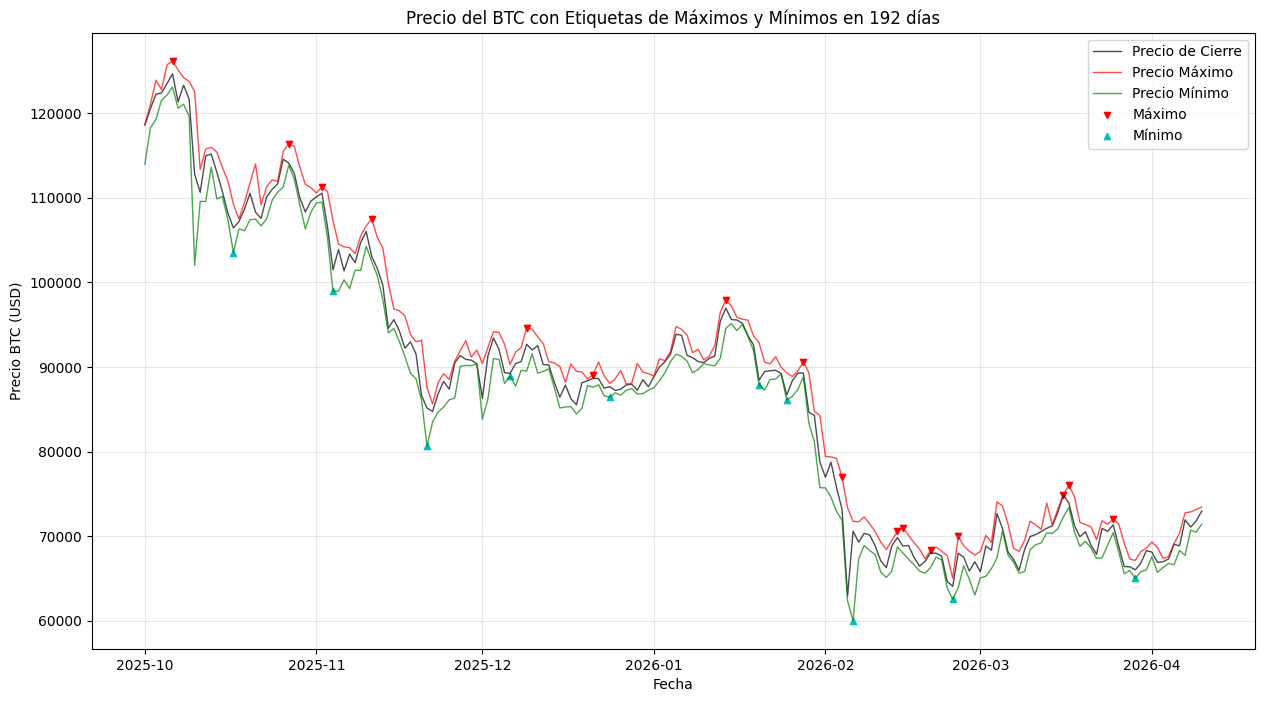

In [12]:
# savgol-ts
graficar_extremos(labels, ['max_savgol-ts','min_savgol-ts'],'2025-10-01')